# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [67]:
!python -m pip install pandas
!python -m pip install  scikit-learn
!python -m pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import sys, platform
print("Python version:", sys.version)
print("Executable:", sys.executable)
print("Architecture:", platform.architecture())

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Executable: c:\Users\Admin\AppData\Local\Python\pythoncore-3.11-64\python.exe
Architecture: ('64bit', 'WindowsPE')


In [69]:
import matplotlib
print(matplotlib.__version__)

3.10.8


In [70]:
!python -m pip install tensorflow ipykernel


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

print("All imports work")
print(tf.__version__)

All imports work
2.21.0


In [72]:
# Load data from csv file
data_appl = pd.read_csv('data_nasdaq_csv/csv/AAPL.csv')
data_appl

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492
...,...,...,...,...,...,...,...
10585,06-12-2022,141.919998,147.070007,64727200,147.300003,142.910004,142.910004
10586,07-12-2022,140.000000,142.190002,69721100,143.369995,140.940002,140.940002
10587,08-12-2022,141.100006,142.360001,62128300,143.520004,142.649994,142.649994
10588,09-12-2022,140.899994,142.339996,76069500,145.570007,142.160004,142.160004


In [73]:
### Split the dataset into time windows to get data samples.

df=data_appl
X_data = []
y_data = []
window_size=30 # Time window for data feature (size of 'number of days').

# Select multiple input features
feature_cols = ['Low', 'High', 'Open', 'Close', 'Adjusted Close', 'Volume']
target_col = 'Close'   # change this if you want to predict Close instead

# Create time-window samples
for i in range(len(df) - window_size):
    # 30 days × 6 features
    data_feature = df[feature_cols].iloc[i:i + window_size].values
    
    # predict the next day's target
    data_label = df[target_col].iloc[i + window_size]
    
    X_data.append(data_feature)
    y_data.append(data_label)

# Convert to numpy arrays
X_data = np.array(X_data)
y_data = np.array(y_data)

print("X_data shape:", X_data.shape)   # (samples, 30, 6)
print("y_data shape:", y_data.shape)   # (samples,)

X_data shape: (10560, 30, 6)
y_data shape: (10560,)


In [74]:
### Split the data into training, validation and test set

# Split data into train, val and test. Note that 'shuffle=False' due to time-series data.
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

# Convert from lists to Numpy arrays for reshaping purpose
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

# Reshape the numpy array to fit the neural network input shape requirement
X_train = X_train.reshape(X_train.shape[0], window_size, 6)
X_val = X_val.reshape(X_val.shape[0], window_size, 6)
X_test = X_test.reshape(X_test.shape[0], window_size, 6)

# Print shape of the training, validation and test set
print("Shape of training set: ", X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ", X_test.shape)

Shape of training set:  (6758, 30, 6)
Shape of validation set:  (1690, 30, 6)
Shape of test set:  (2112, 30, 6)


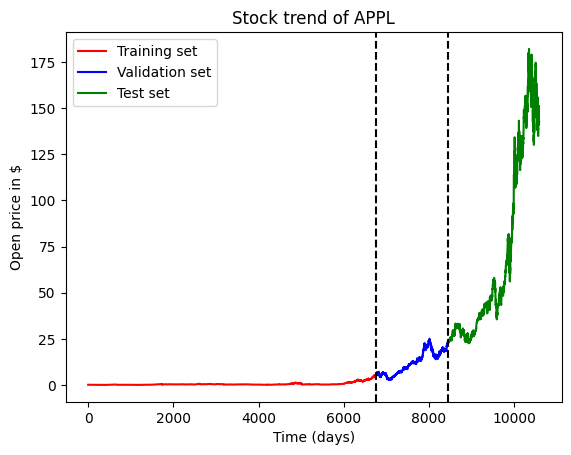

In [75]:
# Visualize the training, validation and test set
df_plot = df[target_col]
df_plot = df_plot.reset_index(drop=False)

# Get lengths of the three subsets
size_train = X_train.shape[0]
size_val = X_val.shape[0]
size_test = X_test.shape[0]

# Plot the subset splits
ax = df_plot.iloc[:size_train,1:2].plot(y=0, color='red', label='Training set')
df_plot.iloc[size_train:size_train+size_val,1:2].plot(y=0, color='blue', label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0],1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of APPL")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train, color='black', linestyle='--')
plt.axvline(x=size_train+size_val, color='black', linestyle='--')
plt.show()

In [76]:
# MinMax normalize the training data: x=(x-min(x)/(max(x)-min(x))
X_train_norm = X_train.copy()
y_train_norm = y_train.copy()
for i in range(0, len(X_train)):
    min_feature = np.min(X_train[i])
    max_feature = np.max(X_train[i])
    X_train_norm[i] = (X_train[i] - min_feature) / (max_feature - min_feature)
    y_train_norm[i] = (y_train[i] - min_feature) / (max_feature - min_feature)

# MinMax normalize the validation data: x=(x-min(x)/(max(x)-min(x))
X_val_norm = X_val.copy()
y_val_norm = y_val.copy()
for i in range(0, len(X_val)):
    min_feature = np.min(X_val[i])
    max_feature = np.max(X_val[i])
    X_val_norm[i] = (X_val[i] - min_feature) / (max_feature - min_feature)
    y_val_norm[i] = (y_val[i] - min_feature) / (max_feature - min_feature)

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_timesteps = X_train_norm.shape[1]
n_features = X_train_norm.shape[2]

model = Sequential([
    Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=(n_timesteps, n_features)),
    # BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(256, kernel_size=3, padding='same', activation='relu'),
    GlobalAveragePooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train_norm, y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100


c:\Users\Admin\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4825e-05 - mae: 8.2808e-04 - mse: 1.4825e-05 - val_loss: 6.8310e-11 - val_mae: 8.0867e-06 - val_mse: 6.8310e-11 - learning_rate: 0.0010
Epoch 2/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.8398e-10 - mae: 1.2840e-05 - mse: 7.8398e-10 - val_loss: 6.1363e-12 - val_mae: 2.2457e-06 - val_mse: 6.1363e-12 - learning_rate: 0.0010
Epoch 3/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.8788e-10 - mae: 5.7815e-06 - mse: 2.8788e-10 - val_loss: 1.3442e-11 - val_mae: 3.6188e-06 - val_mse: 1.3442e-11 - learning_rate: 0.0010
Epoch 4/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0872e-10 - mae: 3.6183e-06 - mse: 1.0872e-10 - val_loss: 5.0996e-11 - val_mae: 7.1342e-06 - val_mse: 5.0996e-11 - learning_rate: 0.0010
Epoch 5/100
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.0917e-11 - mae: 2.6222e-06 - mse: 8.0917e-11 - val_loss: 2.3661e-13 - val_mae: 4.6288e-07 - val_mse: 2.3661e-13 - learning_rate: 0.0010
Epoch 6/100
212/2

In [78]:
# MinMax normalize the test data: norm_x = (x-min(x) / (max(x) - min(x))
# X_test_norm = X_test.copy()
# y_test_norm = y_test.copy()
# for i in range(0, len(X_test)):
#     min_feature = np.min(X_test[i])
#     max_feature = np.max(X_test[i])
#     X_test_norm[i] = (X_test[i] - min_feature) / (max_feature - min_feature)
#     y_test_norm[i] = (y_test[i] - min_feature) / (max_feature - min_feature)

from sklearn.preprocessing import MinMaxScaler
import numpy as np

n_train, n_steps, n_features = X_train.shape

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d   = X_val.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

X_train_norm = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_norm   = x_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_norm  = x_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train_norm = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_val_norm   = y_scaler.transform(y_val.reshape(-1, 1))
y_test_norm  = y_scaler.transform(y_test.reshape(-1, 1))

In [79]:
### Get prediction on the test data and convert the result back to stock price (i.e., de-normalization)
from sklearn.metrics import mean_squared_error

# Get prediction on the test data
y_pred_norm = model.predict(X_test_norm)
y_pred_denorm = y_scaler.inverse_transform(y_pred_norm)
y_test_denorm = y_scaler.inverse_transform(y_test_norm)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [80]:
print("y_test min/max:", y_test.min(), y_test.max())
print("y_test_denorm min/max:", y_test_denorm.min(), y_test_denorm.max() if 'y_test_denorm' in globals() else "not defined")
print("y_pred_norm min/max:", y_pred_norm.min(), y_pred_norm.max())
print("y_pred_denorm min/max:", y_pred_denorm.min(), y_pred_denorm.max())

y_test min/max: 22.584999084472656 182.00999450683597
y_test_denorm min/max: 22.584999084472656 182.00999450683597
y_pred_norm min/max: 0.012928091 0.13874628
y_pred_denorm min/max: 0.1361754 0.9835385


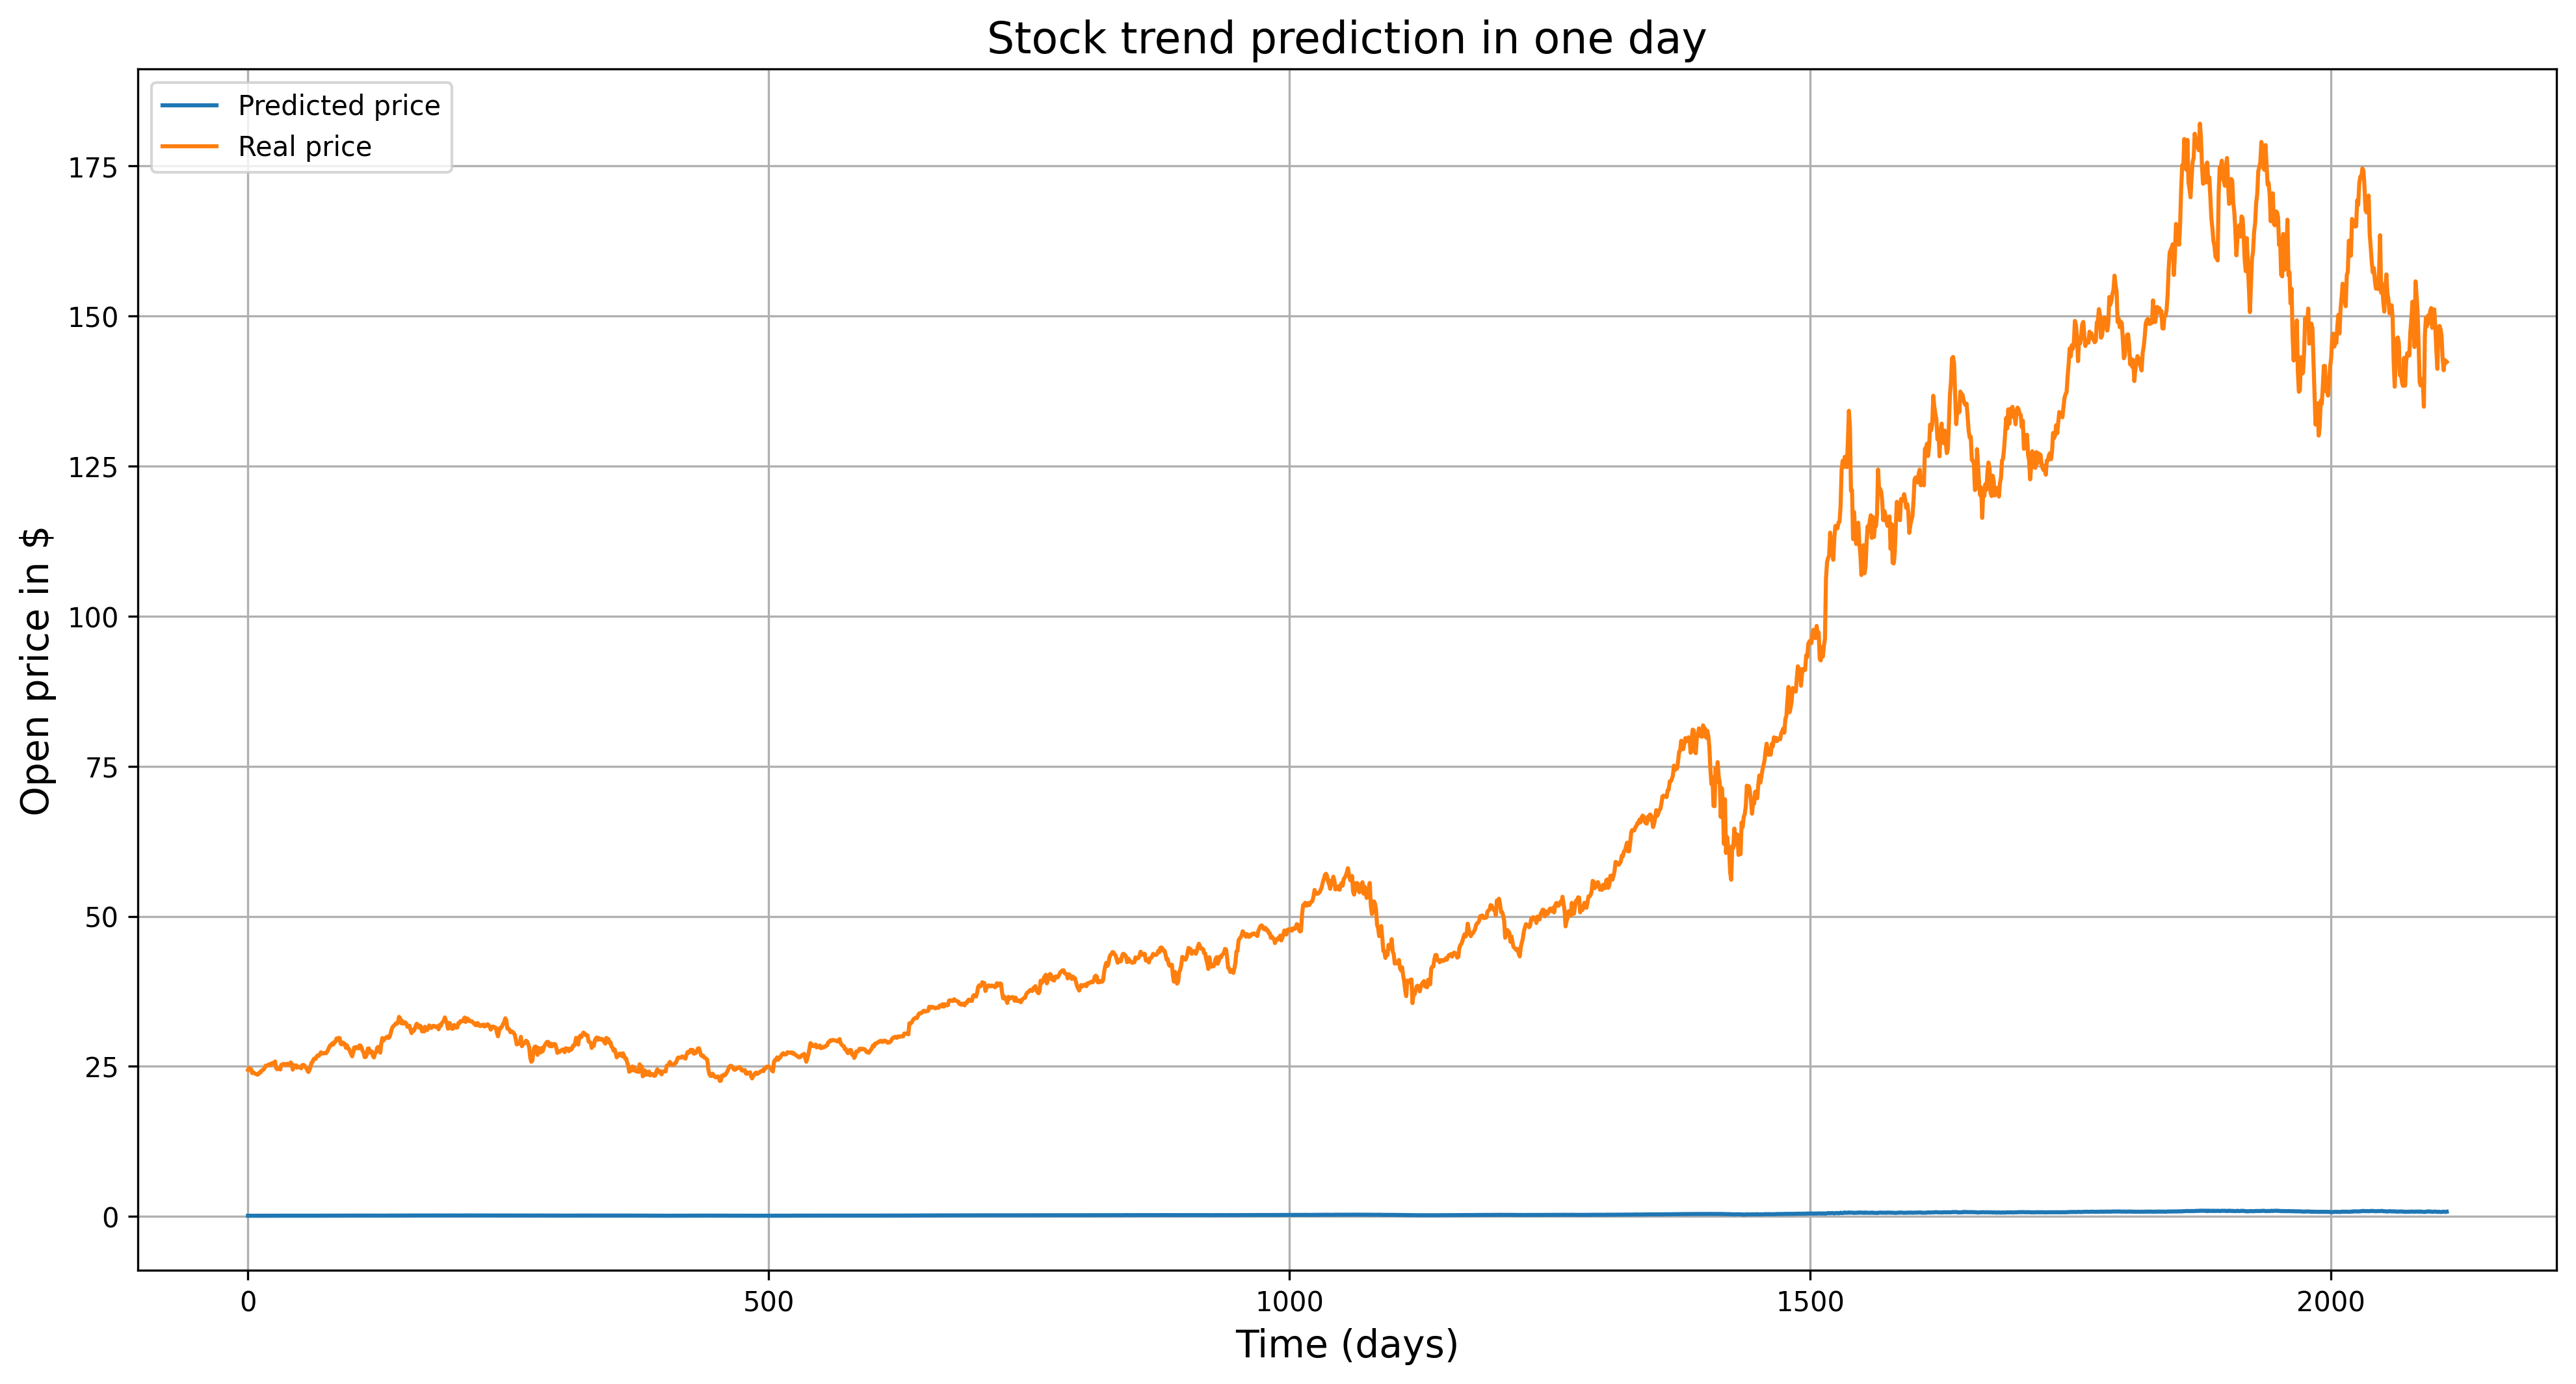

In [81]:
# Convert the result back to stock price (i.e., de-normalization) for visualization purpose
# y_pred_denorm = y_pred_norm
# for i in range(0, len(y_pred_denorm)): # denorm_x = norm_x * (max(x) - min(x)) + min(x)
#     min_feature = np.min(X_test[i])
#     max_feature = np.max(X_test[i])
#     y_pred_denorm[i] = y_pred_norm[i] * (max_feature - min_feature) + min_feature

# Visualize preditec stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm.flatten(), label='Predicted price')
plt.plot(y_test_denorm.flatten(), label='Real price')
plt.title('Stock trend prediction in one day', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()